In [1]:
!pip install anndata==0.8.0

In [16]:
def orthogroup_mapper(orthogroups, label):
    mapping = {}
    for index in orthogroups.index:
        gene_list = orthogroups.loc[index, label]
        if type(gene_list) != float:
            genes = gene_list.split(',')
            for item in genes:
                mapping[item] = index
    return(mapping)

In [17]:
def binary_exp(ct, gdict, marker_dict,org_g_dict):
    heatmap = pd.DataFrame(data = np.zeros((len(ct),len(gene_ord))),index = ct, columns = gene_ord)
    for item in ct:
        if item in marker_dict:
            for g in heatmap.columns:
                org_g = org_g_dict[g]
                if org_g in marker_dict[item]:
                    heatmap.loc[item,g] +=1
                if type(org_g) == float:
                    heatmap.loc[item,g] = np.nan
        else:
            heatmap.loc[item,:] = [np.nan for i in range(len(gene_ord))]
    return(heatmap)

In [2]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad
import math
import csv

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
fn = '../../Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad'
sam_cj = SAM()
sam_cj.load_data(fn)
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i
gene_dict_cj['NaN'] = 'NaN'

In [5]:
fn = '../../Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_03122025.h5ad'
sam_ac = SAM()
sam_ac.load_data(fn)
gene_dict_ac = {}
for i in range(len(sam_ac.adata.var_names)):
    gene_dict_ac[sam_ac.adata.var_names[i]] = i
gene_dict_ac['NaN'] = 'NaN'

In [6]:
fn = '../../Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad'
sam_xt = SAM()
sam_xt.load_data(fn)
gene_dict_xt = {}
for i in range(len(sam_xt.adata.var_names)):
    gene_dict_xt[sam_xt.adata.var_names[i]] = i
gene_dict_xt['NaN'] = 'NaN'

In [7]:
fn = '../../Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad'
sam_dr = SAM()
sam_dr.load_data(fn)
gene_dict_dr = {}
for i in range(len(sam_dr.adata.var_names)):
    gene_dict_dr[sam_dr.adata.var_names[i]] = i
gene_dict_dr['NaN'] = 'NaN'

In [8]:
non_mam = set([i for i in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if not i[:3].isdigit() and not i[3].isdigit() and not i == 'Unlabeled' and not i[3] == 'm']) | set([i for i in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if not i[:3].isdigit() and not i[3].isdigit() and not i == 'Unlabeled' and not i[3] == 'm']) | set([i for i in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if not i[:3].isdigit() and not i[3].isdigit() and not i == 'Unlabeled' and not i[3] == 'm']) | set([i for i in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if not i[:3].isdigit() and not i[3].isdigit() and not i == 'Unlabeled' and not i[3] == 'm']) 

In [9]:
non_mam

{'ac_dr_1',
 'ac_xt_1',
 'ac_xt_2',
 'ac_xt_3',
 'ac_xt_4',
 'cj_ac_1',
 'cj_ac_2',
 'cj_ac_3',
 'cj_ac_4',
 'cj_ac_xt_1',
 'cj_ac_xt_dr_1',
 'cj_ac_xt_dr_3',
 'cj_ac_xt_dr_4',
 'cj_xt_dr_1',
 'cj_xt_dr_2'}

In [10]:
non_mam = [i for i in non_mam if len(i)>7]

In [13]:
otohomo = pd.read_csv('../../OTO_star_nothreshold_missing_le2_expressionthresh_08022026.tsv',delimiter='\t', index_col = 'MM')

In [14]:
orthogroups = pd.read_csv('../../Vert_emapper_allorgs_08012026.tsv',delimiter='\t', index_col = 'Unnamed: 0')

In [18]:
mm_mapping_ortho = orthogroup_mapper(orthogroups,'MM')
mo_mapping_ortho = orthogroup_mapper(orthogroups,'MO')
cj_mapping_ortho = orthogroup_mapper(orthogroups,'CJ')
ac_mapping_ortho = orthogroup_mapper(orthogroups,'AC')
xt_mapping_ortho = orthogroup_mapper(orthogroups,'XT')
dr_mapping_ortho = orthogroup_mapper(orthogroups,'DR')

In [21]:
with open('../../Important_genes/CJ_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/CJ_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_cj = pickle.load(f)
    
with open('../../Important_genes/AC_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/AC_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_ac = pickle.load(f)
    
with open('../../Important_genes/XT_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/XT_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_xt = pickle.load(f)
    
with open('../../Important_genes/DR_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/DR_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_dr = pickle.load(f)

In [23]:
neuropep = pd.read_csv('../../Neuropeptides_receptors_10202025.csv')

In [24]:
R_set = set(neuropep.columns) - set(['Neuropeptide names'])
receptors = set(np.unique([str(x).strip() for x in neuropep[R_set].values.ravel() if pd.notna(x)]))

In [25]:
receptors = list(receptors)
neuropeptides = list(set(neuropep['Neuropeptide names']))

In [26]:
index_order = ['cj_xt_dr_2','cj_ac_xt_dr_4','cj_ac_xt_1','cj_xt_dr_1','cj_ac_xt_dr_1','cj_ac_xt_dr_3']

In [27]:
all_np = neuropeptides + receptors + ['Prdm16','Gata3','Sim1','Dach2','Ebf1','Lhx2']

In [28]:
all_np = [i for i in all_np if i in otohomo.index]

In [29]:
cj_exp = {i:otohomo.loc[i,'CJ'] for i in all_np}
ac_exp = {i:otohomo.loc[i,'AC'] for i in all_np}
xt_exp = {i:otohomo.loc[i,'XT'] for i in all_np}
dr_exp = {i:otohomo.loc[i,'DR'] for i in all_np}

In [30]:
gene_ord = cj_exp.keys()
bi_cj = binary_exp(non_mam,gene_ord,marker_dict_cj,cj_exp)
bi_ac = binary_exp(non_mam,gene_ord,marker_dict_ac,ac_exp)
bi_xt = binary_exp(non_mam,gene_ord,marker_dict_xt,xt_exp)
bi_dr = binary_exp(non_mam,gene_ord,marker_dict_dr,dr_exp)

In [31]:
bi_cj.shape

(6, 149)

In [32]:
bi_cj

,Penk,Ucn,Oxt,Rln3,Pmch,Igf1,Pdyn,Edn1,Chga,Pomc,...,Bdkrb1,Npr2,Vipr1,Ednra,Prdm16,Gata3,Sim1,Dach2,Ebf1,Lhx2
cj_ac_xt_dr_3,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
cj_xt_dr_2,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
cj_ac_xt_1,1.0,1.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
cj_ac_xt_dr_4,0.0,0.0,0.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
cj_ac_xt_dr_1,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
cj_xt_dr_1,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [33]:
cmap = plt.cm.Blues.copy()
cmap.set_bad(color="lightgray")  # color for NaNs

<AxesSubplot:>

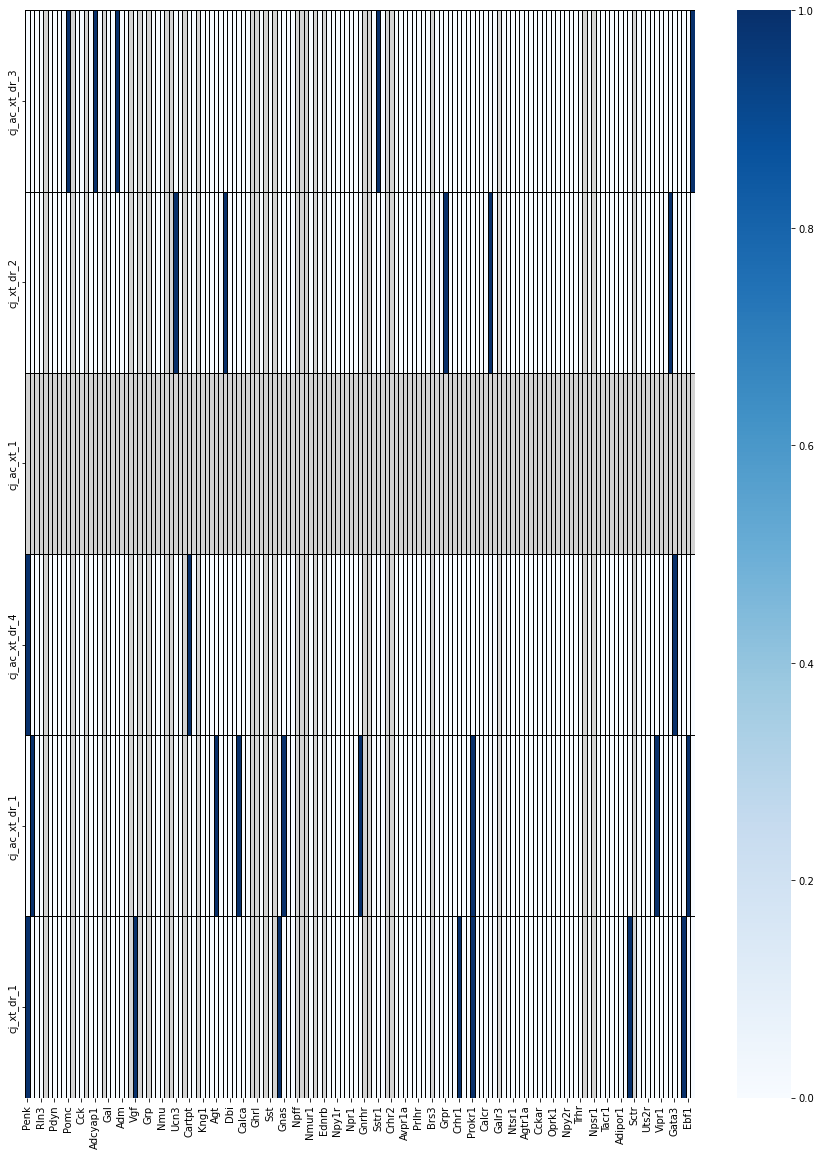

In [34]:
plt.figure(figsize=(15,20))
sns.heatmap(bi_dr, cmap = cmap,  linewidth=0.5, linecolor='black',)

In [35]:
fbi_cj = bi_cj.fillna(0)
fbi_ac = bi_ac.fillna(0)
fbi_xt = bi_xt.fillna(0)
fbi_dr = bi_dr.fillna(0)

In [36]:
fbi_all = fbi_cj + fbi_ac + fbi_xt + fbi_dr

In [37]:
'Crh' in fbi_all.columns

True

In [38]:
fbi_all

,Penk,Ucn,Oxt,Rln3,Pmch,Igf1,Pdyn,Edn1,Chga,Pomc,...,Bdkrb1,Npr2,Vipr1,Ednra,Prdm16,Gata3,Sim1,Dach2,Ebf1,Lhx2
cj_ac_xt_dr_3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
cj_xt_dr_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
cj_ac_xt_1,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,3.0,0.0,3.0,0.0
cj_ac_xt_dr_4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
cj_ac_xt_dr_1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,4.0,3.0
cj_xt_dr_1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0


In [39]:
num_orgs = pd.DataFrame(data = np.zeros((len(fbi_all.index),1)),columns = ['Num orgs'], index = fbi_all.index)
for item in num_orgs.index:
    if item in marker_dict_cj.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_ac.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_xt.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_dr.keys():
        num_orgs.loc[item,'Num orgs'] +=1

In [40]:
cts = num_orgs[num_orgs['Num orgs'] >= 3].index

In [41]:
np.sum(fbi_all, axis = 0)

Penk     4.0
Ucn      3.0
Oxt      0.0
Rln3     0.0
Pmch     0.0
        ... 
Gata3    5.0
Sim1     3.0
Dach2    3.0
Ebf1     8.0
Lhx2     8.0
Length: 149, dtype: float64

In [42]:
fbi_all = fbi_all.loc[cts,:]

In [43]:
fbi_all

,Penk,Ucn,Oxt,Rln3,Pmch,Igf1,Pdyn,Edn1,Chga,Pomc,...,Bdkrb1,Npr2,Vipr1,Ednra,Prdm16,Gata3,Sim1,Dach2,Ebf1,Lhx2
cj_ac_xt_dr_3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
cj_xt_dr_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
cj_ac_xt_1,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,3.0,0.0,3.0,0.0
cj_ac_xt_dr_4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
cj_ac_xt_dr_1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,4.0,3.0
cj_xt_dr_1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0


In [52]:
tot_index = fbi_all.columns[(fbi_all >= 3).any(axis=0)]

In [53]:
tot_index

Index(['Adcyap1', 'Prdm16', 'Gata3', 'Sim1', 'Dach2', 'Ebf1', 'Lhx2'], dtype='object')

In [38]:
column_map = pd.DataFrame(index = fbi_all.columns, columns = ['npcolor'])
for item in fbi_all.columns:
    if item in neuropeptides:
        column_map.loc[item,'npcolor'] = 'Purple'
    elif item in receptors:
        column_map.loc[item,'npcolor'] = 'Green'
    else:
        column_map.loc[item,'npcolor'] = 'Gold'

In [39]:
column_map

,npcolor
Uts2,Purple
Gcg,Purple
Nppc,Purple
Pthlh,Purple
Ucn,Purple
...,...
Gata3,Gold
Sim1,Gold
Dach2,Gold
Ebf1,Gold


In [40]:
fbi_all.shape

(6, 149)

In [41]:
index_order = ['cj_xt_dr_2','cj_ac_xt_dr_4','cj_ac_xt_1','cj_xt_dr_1','cj_ac_xt_dr_1','cj_ac_xt_dr_3']

In [42]:
reindex = ['Pomc','Hcrt','Npvf','Qrfp','Adcyap1','Pdyn','Oprk1','Igf1','Pmch','Trh','Agtr1a','Oxt','Avp','Crh']
reindex.reverse()
reindex = ['Grp','Nts','Pnoc','Gal','Galr1','Agrp','Npy','Sst','Glp1r'] + reindex 
reindex = reindex + ['Prdm16','Gata3','Sim1','Dach2','Ebf1','Lhx2']

In [43]:
fbi_all = fbi_all.loc[:,reindex]

In [44]:
fbi_all = fbi_all.loc[index_order,:]

<AxesSubplot:>

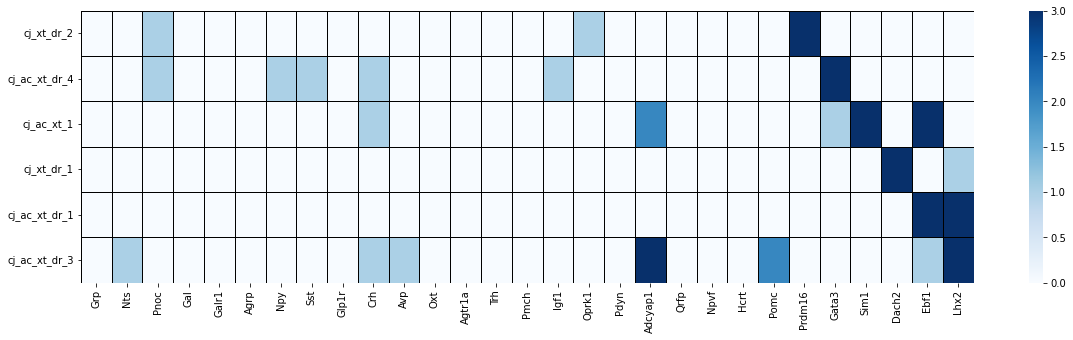

In [45]:
plt.figure(figsize=(20,5))
sns.heatmap(fbi_all, cmap = cmap,  linewidth=0.5, linecolor='black',vmax = 3, vmin = 0)

In [46]:
column_map.loc['Galr1',:]

npcolor    Green
Name: Galr1, dtype: object

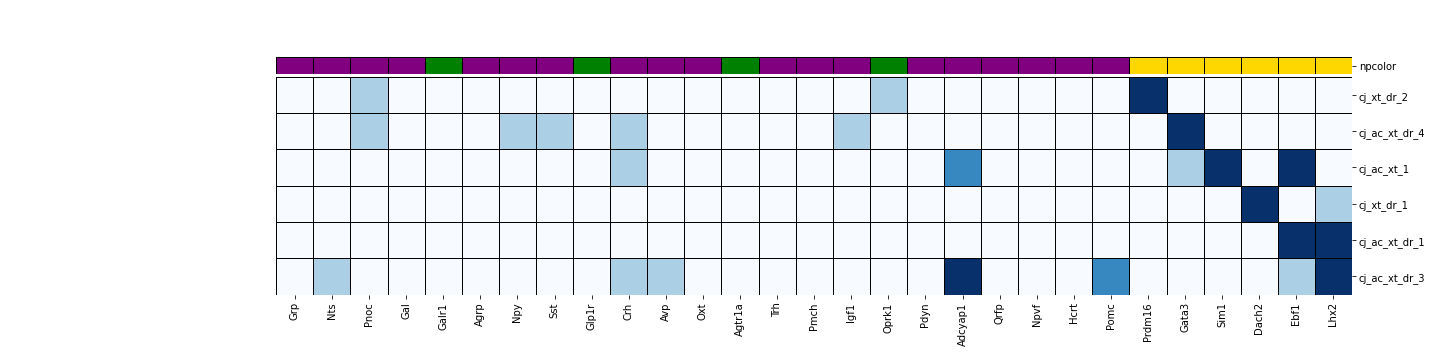

In [47]:
g = sns.clustermap(fbi_all, cmap = cmap,  linewidth=0.5, linecolor='black',vmax = 3, vmin = 0,col_colors = column_map, row_cluster = False, col_cluster = False, figsize = (20,5), cbar_pos = None)
#g.ax_heatmap.set_xticks([])
#g.ax_heatmap.set_yticks([])
colc_ax = g.ax_col_colors
box = colc_ax.get_position()
colc_ax.set_position([
    box.x0,              # left
    box.y0,       # bottom (shift it up a bit)
    box.width,           # keep width
    box.height*2    # reduce height (30% of original)
])
plt.savefig('Figures/Figures_08022026/Nonmam_Neuropeptide_TF_marker_conservation_08042026.svg',bbox_inches='tight')
plt.savefig('Figures/Figures_08022026/Nonmam_Neuropeptide_TF_marker_conservation_08042026.png', dpi = 300)
plt.savefig('Figures/Figures_08022026/Nonmam_Neuropeptide_TF_marker_conservation_08042026.pdf',bbox_inches='tight')